#  Agent Telemetry Data Analysis

This notebook demonstrates how to analyze AI agent telemetry data collected by the Abide AgentKit.

## What we'll cover:
- Loading and parsing JSON log files
- Querying agent behavior patterns
- Performance analysis and metrics
- Visualizing agent workflows
- Error analysis and debugging insights


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import glob
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print(" Libraries loaded successfully!")

 Libraries loaded successfully!


##  Load Agent Log Data

First, let's load all the agent log files and parse them into a pandas DataFrame for analysis.


In [2]:
def load_agent_logs(pattern="*agent_logs*.jsonl"):
    """Load all agent log files matching the pattern."""
    
    log_files = glob.glob(pattern)
    print(f" Found {len(log_files)} log files:")
    for file in log_files:
        print(f"  - {file}")
    
    all_logs = []
    
    for file_path in log_files:
        print(f"\n Loading {file_path}...")
        
        with open(file_path, 'r') as f:
            file_logs = []
            for line_num, line in enumerate(f, 1):
                if line.strip():
                    try:
                        log_entry = json.loads(line.strip())
                        log_entry['source_file'] = file_path
                        log_entry['line_number'] = line_num
                        file_logs.append(log_entry)
                    except json.JSONDecodeError as e:
                        print(f" Error parsing line {line_num}: {e}")
            
            print(f"   Loaded {len(file_logs)} events")
            all_logs.extend(file_logs)
    
    print(f"\n Total events loaded: {len(all_logs)}")
    return all_logs

# Load the logs
raw_logs = load_agent_logs()

 Found 6 log files:
  - agent_logs_20251106_172354.jsonl
  - simple_agent_logs_20251106_172501.jsonl
  - agent_logs_20251106_172301.jsonl
  - simple_agent_logs_20251106_172609.jsonl
  - simple_agent_logs_20251106_172430.jsonl
  - simple_agent_logs_20251106_193810.jsonl

 Loading agent_logs_20251106_172354.jsonl...
   Loaded 0 events

 Loading simple_agent_logs_20251106_172501.jsonl...
   Loaded 10 events

 Loading agent_logs_20251106_172301.jsonl...
   Loaded 0 events

 Loading simple_agent_logs_20251106_172609.jsonl...
   Loaded 10 events

 Loading simple_agent_logs_20251106_172430.jsonl...
   Loaded 0 events

 Loading simple_agent_logs_20251106_193810.jsonl...
   Loaded 10 events

 Total events loaded: 30


In [3]:
def parse_logs_to_dataframe(logs):
    """Convert raw logs to a structured pandas DataFrame."""
    
    parsed_data = []
    
    for log in logs:
        # Base fields
        row = {
            'trace_id': log.get('trace_id'),
            'event_id': log.get('event_id'),
            'event_type': log.get('event_type'),
            'conversation_id': log.get('conversation_id'),
            'run_id': log.get('run_id'),
            'span_id': log.get('span_id'),
            'level': log.get('level'),
            'success': log.get('success'),
            'error': log.get('error'),
            'sampled': log.get('sampled'),
            'source_file': log.get('source_file')
        }
        
        # Agent information
        agent = log.get('agent', {})
        row.update({
            'agent_name': agent.get('name'),
            'agent_role': agent.get('role'),
            'agent_version': agent.get('version')
        })
        
        # Action information
        action = log.get('action', {})
        if action:
            row.update({
                'action_type': action.get('type'),
                'action_name': action.get('name'),
                'action_input': str(action.get('input', ''))[:200],  # Truncate long inputs
                'action_output': str(action.get('output', ''))[:200],  # Truncate long outputs
                'action_success': action.get('success')
            })
        
        # Model call information
        model_call = log.get('model_call', {})
        if model_call:
            row.update({
                'model_backend': model_call.get('backend'),
                'model_name': model_call.get('model'),
                'input_tokens': model_call.get('input_token_count'),
                'output_tokens': model_call.get('output_token_count'),
                'total_tokens': model_call.get('total_token_count')
            })
        
        # Telemetry/timing information
        telemetry = log.get('telemetry', {})
        if telemetry:
            row.update({
                'timestamp_start': telemetry.get('timestamp_start'),
                'timestamp_end': telemetry.get('timestamp_end'),
                'latency_ms': telemetry.get('latency_ms'),
                'timestamp_iso': telemetry.get('timestamp_start_iso'),
                'throughput_tokens_per_sec': telemetry.get('throughput_tokens_per_sec')
            })
        
        # Metadata (flatten common fields)
        metadata = log.get('metadata', {})
        row.update({
            'message': metadata.get('message'),
            'metric_name': metadata.get('metric_name'),
            'metric_value': metadata.get('value'),
            'metric_unit': metadata.get('unit'),
            'error_type': metadata.get('error_type'),
            'environment': metadata.get('environment'),
            'user': metadata.get('user')
        })
        
        # Add raw metadata as JSON string for complex queries
        row['metadata_json'] = json.dumps(metadata) if metadata else None
        
        parsed_data.append(row)
    
    df = pd.DataFrame(parsed_data)
    
    # Convert timestamps
    if 'timestamp_iso' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp_iso'], errors='coerce')
    
    print(f" DataFrame created with {len(df)} rows and {len(df.columns)} columns")
    return df

# Parse logs to DataFrame
df = parse_logs_to_dataframe(raw_logs)

# Display basic info
print(f"\n Data Overview:")
print(f"  • Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"  • Event types: {df['event_type'].value_counts().to_dict()}")
print(f"  • Agents: {df['agent_name'].value_counts().to_dict()}")

 DataFrame created with 30 rows and 38 columns

 Data Overview:
  • Time range: 2025-11-06 17:25:01.899336 to 2025-11-06 19:38:10.963100
  • Event types: {'log': 12, 'metric': 6, 'agent_run_start': 3, 'model_call_start': 3, 'agent_run_end': 3, 'error': 3}
  • Agents: {'SimpleTestAgent': 30}


##  Basic Data Exploration

Let's start with basic exploration of our agent telemetry data.


In [4]:

print(" First 5 events:")
display(df.head())

print("\n Data types and non-null counts:")
print(df.info())

 First 5 events:


,trace_id,event_id,event_type,conversation_id,run_id,span_id,level,success,error,sampled,...,action_name,action_input,action_output,action_success,model_backend,model_name,input_tokens,output_tokens,total_tokens,timestamp
0,6652c09e-4f43-4a34-8a5f-d359b85bab9f,88ee9e4d-fe96-4458-ad4f-3d5aeb460a43,log,None,None,None,info,True,None,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-06 17:25:01.899336
1,178114b4-503e-4b30-a334-52a5458afc80,890286ec-9131-41ba-a226-b42aa552563a,log,None,None,None,info,True,None,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-06 17:25:01.899789
2,16f8a610-6612-4cb0-ac00-0d5c864280a7,ec9f6576-45e5-44df-83e8-bf0c20a43cf1,agent_run_start,e04e1448-54eb-4d29-ba33-43db65de2c5d,e04e1448-54eb-4d29-ba33-43db65de2c5d,b13a6c65-4071-41d8-a662-3835981d66f0,info,True,None,True,...,weather_task,{},,True,NaN,NaN,NaN,NaN,NaN,2025-11-06 17:25:02.005283
3,4481a3fe-0532-4724-8e8f-1786b9e95ba6,57380bf5-997a-4984-85cd-cf1bec2d6f2d,log,e04e1448-54eb-4d29-ba33-43db65de2c5d,e04e1448-54eb-4d29-ba33-43db65de2c5d,b13a6c65-4071-41d8-a662-3835981d66f0,info,True,None,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-06 17:25:02.006037
4,c6a5f71f-3786-4cdb-87a2-1f5efbf01c39,1297ccdc-0d98-474a-9fe9-1f8260675714,model_call_start,None,None,None,info,True,None,True,...,NaN,NaN,NaN,NaN,openai,gpt-4,NaN,NaN,NaN,2025-11-06 17:25:02.006546



 Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   trace_id                   30 non-null     object        
 1   event_id                   30 non-null     object        
 2   event_type                 30 non-null     object        
 3   conversation_id            12 non-null     object        
 4   run_id                     12 non-null     object        
 5   span_id                    12 non-null     object        
 6   level                      30 non-null     object        
 7   success                    30 non-null     bool          
 8   error                      3 non-null      object        
 9   sampled                    30 non-null     bool          
 10  source_file                30 non-null     object        
 11  agent_name                 30 non-null 

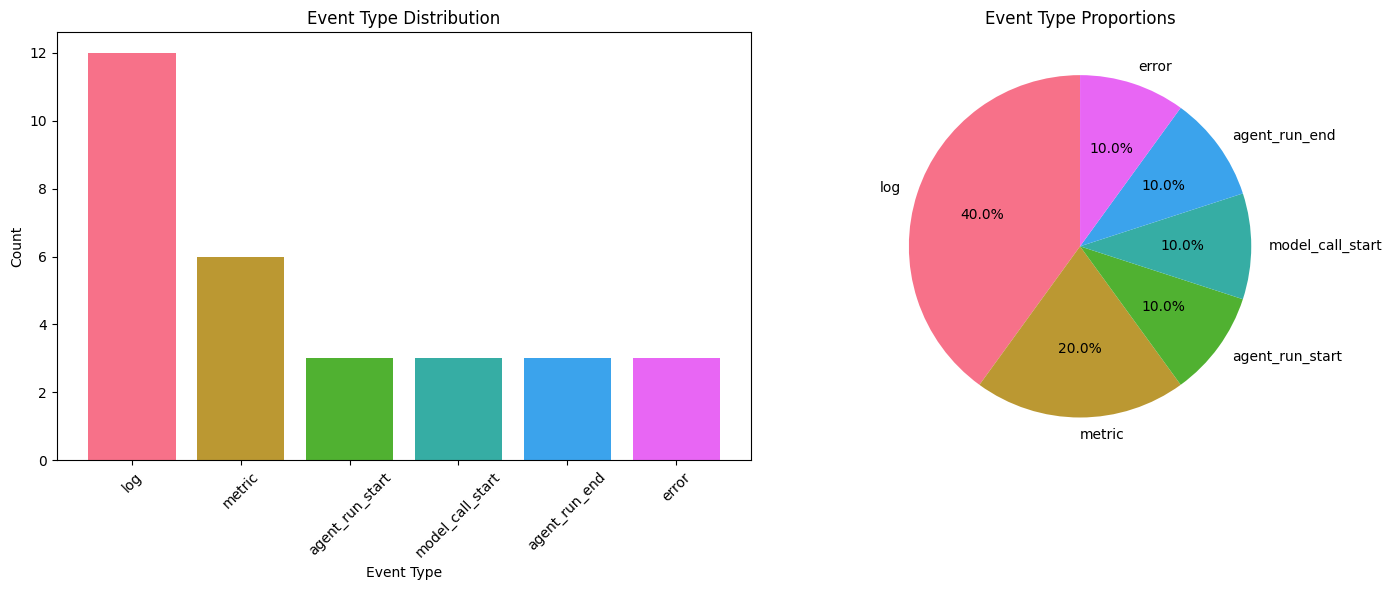

 Event Type Summary:
  • log: 12 events (40.0%)
  • metric: 6 events (20.0%)
  • agent_run_start: 3 events (10.0%)
  • model_call_start: 3 events (10.0%)
  • agent_run_end: 3 events (10.0%)
  • error: 3 events (10.0%)


In [5]:
# Event type distribution with visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Event type counts
event_counts = df['event_type'].value_counts()
ax1.bar(event_counts.index, event_counts.values, color=sns.color_palette("husl", len(event_counts)))
ax1.set_title( 'Event Type Distribution')
ax1.set_xlabel('Event Type')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Event type pie chart
ax2.pie(event_counts.values, labels=event_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Event Type Proportions')

plt.tight_layout()
plt.show()

print(" Event Type Summary:")
for event_type, count in event_counts.items():
    percentage = (count / len(df)) * 100
    print(f"  • {event_type}: {count} events ({percentage:.1f}%)")

##  Agent Behavior Queries

Let's run some interesting queries to understand agent behavior patterns.


In [6]:
print(" AGENT BEHAVIOR ANALYSIS")
print("=" * 50)

# Query 1: Most active agents
print("\n1⃣ Most Active Agents:")
agent_activity = df['agent_name'].value_counts()
print(agent_activity)

# Query 2: Model usage patterns
print("\n2⃣ Model Usage Patterns:")
model_usage = df[df['model_name'].notna()]['model_name'].value_counts()
print(model_usage)

# Query 3: Performance analysis
print("\n3⃣ Performance Analysis:")
print("Latency Statistics (ms):")
latency_stats = df['latency_ms'].describe()
print(latency_stats)

# Query 4: Error analysis
print("\n4⃣ Error Analysis:")
errors = df[df['success'] == False]
if len(errors) > 0:
    print(f"Total errors: {len(errors)}")
    error_types = errors['error_type'].value_counts()
    print("Error types:")
    print(error_types)
    
    print("\nError messages:")
    for idx, row in errors[['timestamp', 'agent_name', 'error', 'message']].iterrows():
        print(f"  • {row['timestamp']}: {row['agent_name']} - {row['error']}")
else:
    print("No errors found! ")

# Query 5: Agent workflow analysis (trace events by run_id)
print("\n5⃣ Agent Workflow Analysis:")
workflows = df[df['run_id'].notna()].groupby('run_id').agg({
    'event_type': 'count',
    'latency_ms': 'sum',
    'total_tokens': 'sum',
    'success': 'all',
    'agent_name': 'first',
    'timestamp': ['min', 'max']
}).round(2)

if len(workflows) > 0:
    workflows.columns = ['total_events', 'total_latency_ms', 'total_tokens', 'all_success', 'agent', 'start_time', 'end_time']
    workflows['duration_seconds'] = (workflows['end_time'] - workflows['start_time']).dt.total_seconds()
    print(workflows)
else:
    print("No workflow data found")

 AGENT BEHAVIOR ANALYSIS

1⃣ Most Active Agents:
agent_name
SimpleTestAgent    30
Name: count, dtype: int64

2⃣ Model Usage Patterns:
model_name
gpt-4    3
Name: count, dtype: int64

3⃣ Performance Analysis:
Latency Statistics (ms):
count      6.000000
mean     104.223808
std        2.358290
min      102.345228
25%      102.710724
50%      103.402853
75%      104.680061
max      108.606100
Name: latency_ms, dtype: float64

4⃣ Error Analysis:
Total errors: 3
Error types:
error_type
ValueError    3
Name: count, dtype: int64

Error messages:
  • 2025-11-06 17:25:02.221706: SimpleTestAgent - Simulated API timeout
  • 2025-11-06 17:26:10.049187: SimpleTestAgent - Simulated API timeout
  • 2025-11-06 19:38:10.962743: SimpleTestAgent - Simulated API timeout

5⃣ Agent Workflow Analysis:
                                      total_events  total_latency_ms  \
run_id                                                                 
74d085a4-352b-4262-b7c5-1b038b9a7f52             4            103.

##  Custom Query Examples

Here are some custom queries you can modify for your specific analysis needs.


In [7]:
# Custom Query 1: Find slow operations (latency > 100ms)
print(" Slow Operations (>100ms):")
slow_ops = df[df['latency_ms'] > 100][['timestamp', 'event_type', 'agent_name', 'latency_ms', 'message']]
print(f"Found {len(slow_ops)} slow operations")
if len(slow_ops) > 0:
    display(slow_ops.head())

# Custom Query 2: Model call performance comparison
print("\n Model Performance Comparison:")
model_perf = df[df['model_name'].notna()].groupby(['model_name', 'model_backend']).agg({
    'latency_ms': ['mean', 'median', 'std'],
    'total_tokens': ['mean', 'sum'],
    'event_id': 'count'
}).round(2)

if len(model_perf) > 0:
    model_perf.columns = ['avg_latency', 'median_latency', 'std_latency', 'avg_tokens', 'total_tokens', 'call_count']
    print(model_perf)

# Custom Query 3: Filter by specific conditions
print("\n Custom Filtering Examples:")
print("# Filter by agent name:")
agent_data = df[df['agent_name'] == 'SimpleTestAgent']
print(f"Events for SimpleTestAgent: {len(agent_data)}")

print("\n# Filter by event type:")
model_calls = df[df['event_type'] == 'model_call_start']
print(f"Model call events: {len(model_calls)}")

print("\n# Complex filtering:")
slow_model_calls = df[(df['event_type'] == 'model_call_start') & (df['latency_ms'] > 50)]
print(f"Slow model calls (>50ms): {len(slow_model_calls)}")

# Custom Query 4: Metric trends
print("\n Custom Metrics Analysis:")
metrics = df[df['event_type'] == 'metric']
if len(metrics) > 0:
    metric_summary = metrics.groupby('metric_name').agg({
        'metric_value': ['count', 'mean', 'min', 'max', 'std'],
        'metric_unit': 'first'
    }).round(2)
    
    metric_summary.columns = ['count', 'mean', 'min', 'max', 'std', 'unit']
    print(metric_summary)
else:
    print("No metrics found")

 Slow Operations (>100ms):
Found 6 slow operations


,timestamp,event_type,agent_name,latency_ms,message
4,2025-11-06 17:25:02.006546,model_call_start,SimpleTestAgent,105.086803,None
6,2025-11-06 17:25:02.005247,agent_run_end,SimpleTestAgent,108.606100,None
14,2025-11-06 17:26:09.840326,model_call_start,SimpleTestAgent,102.345228,None
16,2025-11-06 17:26:09.839875,agent_run_end,SimpleTestAgent,103.459835,None
24,2025-11-06 19:38:10.755739,model_call_start,SimpleTestAgent,102.499008,None



 Model Performance Comparison:
                          avg_latency  median_latency  std_latency  \
model_name model_backend                                             
gpt-4      openai              103.31           102.5         1.54   

                          avg_tokens  total_tokens  call_count  
model_name model_backend                                        
gpt-4      openai                NaN           0.0           3  

 Custom Filtering Examples:
# Filter by agent name:
Events for SimpleTestAgent: 30

# Filter by event type:
Model call events: 3

# Complex filtering:
Slow model calls (>50ms): 3

 Custom Metrics Analysis:
               count   mean    min    max  std    unit
metric_name                                           
response_time      3  250.5  250.5  250.5  0.0      ms
tokens_used        3   68.0   68.0   68.0  0.0  tokens


##  Export Analysis Results

Save your analysis results for further use and create summary reports.


In [8]:
# Export analysis results
print(" EXPORT ANALYSIS RESULTS")
print("=" * 50)

# Save processed DataFrame
output_file = f"agent_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
df.to_csv(output_file, index=False)
print(f" Processed data saved to: {output_file}")

# Create summary report
summary_report = {
    'analysis_timestamp': datetime.now().isoformat(),
    'total_events': len(df),
    'event_types': df['event_type'].value_counts().to_dict(),
    'agents': df['agent_name'].value_counts().to_dict(),
    'time_range': {
        'start': str(df['timestamp'].min()) if 'timestamp' in df.columns else None,
        'end': str(df['timestamp'].max()) if 'timestamp' in df.columns else None
    },
    'performance_stats': {
        'avg_latency_ms': df['latency_ms'].mean() if df['latency_ms'].notna().any() else None,
        'total_tokens': df['total_tokens'].sum() if df['total_tokens'].notna().any() else None,
        'success_rate': (df['success'].mean() * 100) if df['success'].notna().any() else None
    }
}

summary_file = f"agent_summary_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(summary_file, 'w') as f:
    json.dump(summary_report, f, indent=2, default=str)

print(f" Summary report saved to: {summary_file}")

print("\n Analysis Summary:")
print(json.dumps(summary_report, indent=2, default=str))

 EXPORT ANALYSIS RESULTS
 Processed data saved to: agent_analysis_20251106_210203.csv
 Summary report saved to: agent_summary_20251106_210203.json

 Analysis Summary:
{
  "analysis_timestamp": "2025-11-06T21:02:03.452374",
  "total_events": 30,
  "event_types": {
    "log": 12,
    "metric": 6,
    "agent_run_start": 3,
    "model_call_start": 3,
    "agent_run_end": 3,
    "error": 3
  },
  "agents": {
    "SimpleTestAgent": 30
  },
  "time_range": {
    "start": "2025-11-06 17:25:01.899336",
    "end": "2025-11-06 19:38:10.963100"
  },
  "performance_stats": {
    "avg_latency_ms": 104.22380765279134,
    "total_tokens": null,
    "success_rate": 90.0
  }
}
